In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models & Metrics
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Explainability
import shap

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print("DATA INGESTION & FEATURE PREPARATION")
data_path = os.path.join('data', 'all_months_features.csv')

if os.path.exists(data_path):
    df_raw = pd.read_csv(data_path)
    print(f"✓ Feature dataset loaded successfully. Shape: {df_raw.shape}")
else:
    raise FileNotFoundError(f"File not found at '{data_path}'. Run step 04 first.")

/Users/bruker/Desktop/Multi-Target Price Forecasting /.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATA INGESTION & FEATURE PREPARATION
✓ Feature dataset loaded successfully. Shape: (798, 77)


In [2]:
# 1. Do NOT drop rows globally before splitting; instead, let Month 10 be the target for Month 9 features.
df = df_raw.copy()
df['month_idx'] = df.groupby('Product_Name').cumcount() + 1
df = df.sort_values(by=['Product_Name', 'month_idx']).reset_index(drop=True)

targets_base = ['Min_Price', 'Avg_Price', 'Max_Price']
targets_next = ['Min_Price_next', 'Avg_Price_next', 'Max_Price_next']

for base_col, next_col in zip(targets_base, targets_next):
    df[next_col] = df.groupby('Product_Name')[base_col].shift(-1)

# Keep up to month 9 as our modeling base (since Month 9 features can look ahead to Month 10 targets)
df_clean = df[df['month_idx'] <= 9].copy().reset_index(drop=True)

# Drop only rows where the next target is missing (which should only affect the very end if data is missing)
df_clean = df_clean.dropna(subset=targets_next).copy().reset_index(drop=True)

In [3]:
# Separate Features and Targets
non_feature_cols = [
    'Product_Name', 'Category', 'Unit', 'unit_canonical', 'month_name',
    'bs_year', 'bs_month'
] + targets_base + targets_next

feature_cols = [col for col in df_clean.columns if col not in non_feature_cols]

X = df_clean[feature_cols].copy().apply(pd.to_numeric, errors='coerce').fillna(0)
y = df_clean[targets_next].copy().fillna(0)

In [4]:
# Time-based Split: Train (<=7), Valid (==8), Test (==9)
train_mask = (df_clean['month_idx'] <= 7).values
valid_mask = (df_clean['month_idx'] == 8).values
test_mask = (df_clean['month_idx'] == 9).values  # Features from Month 9 -> Target is Month 10

X_train, y_train = X[train_mask], y[train_mask]
X_valid, y_valid = X[valid_mask], y[valid_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"✓ Training samples: {X_train.shape[0]}")
print(f"✓ Validation samples: {X_valid.shape[0]}")
print(f"✓ Testing samples ( predicting Month 10 ): {X_test.shape[0]}")

✓ Training samples: 534
✓ Validation samples: 58
✓ Testing samples ( predicting Month 10 ): 49


In [5]:
print("RANDOM FOREST MODEL & PREDICTIONS (TEST & ALL)")
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model = MultiOutputRegressor(rf_base)
rf_model.fit(X_train, y_train)

RANDOM FOREST MODEL & PREDICTIONS (TEST & ALL)


,estimator,RandomForestR...ndom_state=42)
,n_jobs,None
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [6]:
# Test Set Predictions
y_pred_rf_test = rf_model.predict(X_test)

rf_metrics = {}
for i, col in enumerate(targets_next):
    actual = y_test.iloc[:, i].values
    pred = y_pred_rf_test[:, i]
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    rf_metrics[col] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"  [RF Test] {col} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")

  [RF Test] Min_Price_next -> MAE: 32.96, RMSE: 64.18, R²: 0.661
  [RF Test] Avg_Price_next -> MAE: 39.98, RMSE: 75.22, R²: 0.636
  [RF Test] Max_Price_next -> MAE: 42.14, RMSE: 75.36, R²: 0.688


In [7]:
# Random Forest Test Results CSV Export
df_rf_test_res = df_clean[test_mask][['Product_Name', 'month_idx']].copy().reset_index(drop=True)
for i, col in enumerate(targets_next):
    df_rf_test_res[f'Actual_{col}'] = y_test.iloc[:, i].values
    df_rf_test_res[f'Predicted_{col}'] = np.round(y_pred_rf_test[:, i], 2)
rf_test_path = os.path.join('data', 'RF_test_forecast_results.csv')
df_rf_test_res.to_csv(rf_test_path, index=False)
print(f"✓ RF Test predictions saved to '{rf_test_path}'")

✓ RF Test predictions saved to 'data/RF_test_forecast_results.csv'


In [8]:
# Random Forest All-Months Predictions CSV Export
y_pred_rf_all = rf_model.predict(X)
df_rf_all_res = df_clean[['Product_Name', 'month_idx']].copy().reset_index(drop=True)
for i, col in enumerate(targets_next):
    df_rf_all_res[f'Actual_{col}'] = y[col].values
    df_rf_all_res[f'Predicted_{col}'] = np.round(y_pred_rf_all[:, i], 2)
rf_all_path = os.path.join('data', 'RF_all_months_forecast_results.csv')
df_rf_all_res.to_csv(rf_all_path, index=False)
print(f"✓ RF All-Months predictions saved to '{rf_all_path}'")

✓ RF All-Months predictions saved to 'data/RF_all_months_forecast_results.csv'


In [9]:
print("LIGHTGBM MODEL & PREDICTIONS (TEST & ALL)")
lgb_base = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)
lgb_model = MultiOutputRegressor(lgb_base)
lgb_model.fit(X_train, y_train)

LIGHTGBM MODEL & PREDICTIONS (TEST & ALL)


,estimator,LGBMRegressor... verbose=-1)
,n_jobs,None
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,150
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [10]:
# Test Set Predictions with Constraint Enforcement (Min <= Avg <= Max)
y_pred_lgb_test = lgb_model.predict(X_test)
y_pred_lgb_test[:, 0] = np.minimum(y_pred_lgb_test[:, 0], y_pred_lgb_test[:, 1])
y_pred_lgb_test[:, 2] = np.maximum(y_pred_lgb_test[:, 2], y_pred_lgb_test[:, 1])

lgb_metrics = {}
for i, col in enumerate(targets_next):
    actual = y_test.iloc[:, i].values
    pred = y_pred_lgb_test[:, i]
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    lgb_metrics[col] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"  [LightGBM Test] {col} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")

  [LightGBM Test] Min_Price_next -> MAE: 28.30, RMSE: 60.11, R²: 0.703
  [LightGBM Test] Avg_Price_next -> MAE: 34.95, RMSE: 73.59, R²: 0.652
  [LightGBM Test] Max_Price_next -> MAE: 36.21, RMSE: 71.91, R²: 0.716


In [11]:
# LightGBM Test Results CSV Export
df_lgb_test_res = df_clean[test_mask][['Product_Name', 'month_idx']].copy().reset_index(drop=True)
for i, col in enumerate(targets_next):
    df_lgb_test_res[f'Actual_{col}'] = y_test.iloc[:, i].values
    df_lgb_test_res[f'Predicted_{col}'] = np.round(y_pred_lgb_test[:, i], 2)
lgb_test_path = os.path.join('data', 'LightGBM_test_forecast_results.csv')
df_lgb_test_res.to_csv(lgb_test_path, index=False)
print(f"✓ LightGBM Test predictions saved to '{lgb_test_path}'")

✓ LightGBM Test predictions saved to 'data/LightGBM_test_forecast_results.csv'


In [12]:
# LightGBM All-Months Predictions with Constraint Enforcement CSV Export
y_pred_lgb_all = lgb_model.predict(X)
y_pred_lgb_all[:, 0] = np.minimum(y_pred_lgb_all[:, 0], y_pred_lgb_all[:, 1])
y_pred_lgb_all[:, 2] = np.maximum(y_pred_lgb_all[:, 2], y_pred_lgb_all[:, 1])

df_lgb_all_res = df_clean[['Product_Name', 'month_idx']].copy().reset_index(drop=True)
for i, col in enumerate(targets_next):
    df_lgb_all_res[f'Actual_{col}'] = y[col].values
    df_lgb_all_res[f'Predicted_{col}'] = np.round(y_pred_lgb_all[:, i], 2)
lgb_all_path = os.path.join('data', 'LightGBM_all_months_forecast_results.csv')
df_lgb_all_res.to_csv(lgb_all_path, index=False)
print(f"✓ LightGBM All-Months predictions saved to '{lgb_all_path}'")

✓ LightGBM All-Months predictions saved to 'data/LightGBM_all_months_forecast_results.csv'


CONFUSION MATRIX CLASSIFICATION EVALUATION
Random Forest
[[16 16]
 [ 9  8]]
Accuracy: 0.4897959183673469

LightGBM
[[20 12]
 [ 9  8]]
Accuracy: 0.5714285714285714


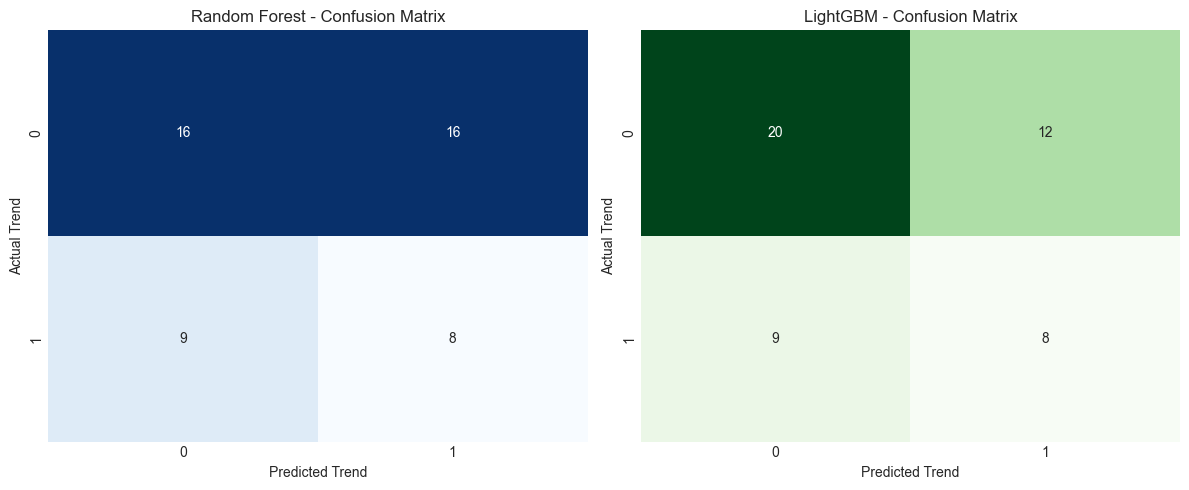

In [15]:
print("CONFUSION MATRIX CLASSIFICATION EVALUATION")

# Baseline = current month's average price (Month 9)
baseline_test_vals = df_clean.loc[test_mask, 'Avg_Price'].values

# Index of Avg_Price_next
avg_idx = targets_next.index("Avg_Price_next")

# Actual direction
actual_direction = (
    y_test.iloc[:, avg_idx].values > baseline_test_vals
).astype(int)

# RF prediction direction
rf_pred_direction = (
    y_pred_rf_test[:, avg_idx] > baseline_test_vals
).astype(int)

# LightGBM prediction direction
lgb_pred_direction = (
    y_pred_lgb_test[:, avg_idx] > baseline_test_vals
).astype(int)

# Confusion matrices
cm_rf = confusion_matrix(actual_direction, rf_pred_direction)
cm_lgb = confusion_matrix(actual_direction, lgb_pred_direction)

print("Random Forest")
print(cm_rf)
print("Accuracy:", accuracy_score(actual_direction, rf_pred_direction))

print("\nLightGBM")
print(cm_lgb)
print("Accuracy:", accuracy_score(actual_direction, lgb_pred_direction))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Random Forest - Confusion Matrix')
axes[0].set_xlabel('Predicted Trend')
axes[0].set_ylabel('Actual Trend')

sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('LightGBM - Confusion Matrix')
axes[1].set_xlabel('Predicted Trend')
axes[1].set_ylabel('Actual Trend')
plt.tight_layout()
plt.show()

In [16]:
print("MODEL PERFORMANCE COMPARISON TABLE ")
comparison_data = []
for col in targets_next:
    comparison_data.append({
        'Target': col,
        'RF_MAE': round(rf_metrics[col]['MAE'], 2), 'LGB_MAE': round(lgb_metrics[col]['MAE'], 2),
        'RF_RMSE': round(rf_metrics[col]['RMSE'], 2), 'LGB_RMSE': round(lgb_metrics[col]['RMSE'], 2),
        'RF_R2': round(rf_metrics[col]['R2'], 3), 'LGB_R2': round(lgb_metrics[col]['R2'], 3)
    })
df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

MODEL PERFORMANCE COMPARISON TABLE 
        Target  RF_MAE  LGB_MAE  RF_RMSE  LGB_RMSE  RF_R2  LGB_R2
Min_Price_next   32.96    28.30    64.18     60.11  0.661   0.703
Avg_Price_next   39.98    34.95    75.22     73.59  0.636   0.652
Max_Price_next   42.14    36.21    75.36     71.91  0.688   0.716


In [15]:
# Baseline values for the test set (using last month's price or baseline)
baseline_test_vals = df_clean.loc[test_mask, 'Avg_Price'].values

rf_metrics_results = []

for i, col in enumerate(targets_next):
    y_act = y_test.iloc[:, i].values if hasattr(y_test, 'iloc') else y_test[:, i]
    y_rf_pred = y_pred_rf_test[:, i]
    
    # Convert regression prices to binary price movement direction (1 if > baseline, else 0)
    act_dir = (y_act > baseline_test_vals).astype(int)
    pred_dir = (y_rf_pred > baseline_test_vals).astype(int)
    
    # Calculate metrics
    acc = accuracy_score(act_dir, pred_dir)
    prec = precision_score(act_dir, pred_dir, zero_division=0)
    rec = recall_score(act_dir, pred_dir, zero_division=0)
    f1 = f1_score(act_dir, pred_dir, zero_division=0)
    
    rf_metrics_results.append({
        'Target': col,
        'Model': 'Random Forest',
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

df_rf_class_metrics = pd.DataFrame(rf_metrics_results)
print("RANDOM FOREST CLASSIFICATION METRICS ")
display(df_rf_class_metrics)

RANDOM FOREST CLASSIFICATION METRICS 


,Target,Model,Accuracy,Precision,Recall,F1-Score
0,Min_Price_next,Random Forest,0.8776,0.3333,1.0000,0.5000
1,Avg_Price_next,Random Forest,0.4898,0.3333,0.4706,0.3902
2,Max_Price_next,Random Forest,0.7755,0.8780,0.8571,0.8675


In [16]:
# Ensure y_pred_lgb_test holds your LightGBM test predictions
baseline_test_vals = df_clean.loc[test_mask, 'Avg_Price'].values

lgb_metrics_results = []

for i, col in enumerate(targets_next):
    y_act = y_test.iloc[:, i].values if hasattr(y_test, 'iloc') else y_test[:, i]
    y_lgb_pred = y_pred_lgb_test[:, i]
    
    # Convert regression prices to binary price movement direction (1 if > baseline, else 0)
    act_dir = (y_act > baseline_test_vals).astype(int)
    pred_dir = (y_lgb_pred > baseline_test_vals).astype(int)
    
    # Calculate metrics
    acc = accuracy_score(act_dir, pred_dir)
    prec = precision_score(act_dir, pred_dir, zero_division=0)
    rec = recall_score(act_dir, pred_dir, zero_division=0)
    f1 = f1_score(act_dir, pred_dir, zero_division=0)
    
    lgb_metrics_results.append({
        'Target': col,
        'Model': 'LightGBM',
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

df_lgb_class_metrics = pd.DataFrame(lgb_metrics_results)
print("LIGHTGBM CLASSIFICATION METRICS")
display(df_lgb_class_metrics)

LIGHTGBM CLASSIFICATION METRICS


,Target,Model,Accuracy,Precision,Recall,F1-Score
0,Min_Price_next,LightGBM,0.9184,0.3333,0.3333,0.3333
1,Avg_Price_next,LightGBM,0.5714,0.4000,0.4706,0.4324
2,Max_Price_next,LightGBM,0.8571,0.9268,0.9048,0.9157


In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

print("RANDOM FOREST REGRESSION METRICS WITH MAPE")

for i, col in enumerate(targets_next):

    actual = y_test.iloc[:, i].values
    pred = y_pred_rf_test[:, i]

    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)

    print(f"\n{col}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.3f}")

RANDOM FOREST REGRESSION METRICS WITH MAPE

Min_Price_next
MAE  : 32.96
RMSE : 64.18
R²   : 0.661

Avg_Price_next
MAE  : 39.98
RMSE : 75.22
R²   : 0.636

Max_Price_next
MAE  : 42.14
RMSE : 75.36
R²   : 0.688


In [18]:
print("LIGHTGBM REGRESSION METRICS WITH MAPE")
for i, col in enumerate(targets_next):

    actual = y_test.iloc[:, i].values
    pred = y_pred_lgb_test[:, i]

    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)

    print(f"\n{col}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.3f}")

LIGHTGBM REGRESSION METRICS WITH MAPE

Min_Price_next
MAE  : 28.30
RMSE : 60.11
R²   : 0.703

Avg_Price_next
MAE  : 34.95
RMSE : 73.59
R²   : 0.652

Max_Price_next
MAE  : 36.21
RMSE : 71.91
R²   : 0.716


In [19]:
# Last Value (Persistence) Baseline

baseline_pred = pd.DataFrame({
    "Min_Price_next": X_test["Min_Price_lag1"].values,
    "Avg_Price_next": X_test["Avg_Price_lag1"].values,
    "Max_Price_next": X_test["Max_Price_lag1"].values
})

baseline_pred.head()

,Min_Price_next,Avg_Price_next,Max_Price_next
0,225.0,255.0,330.0
1,60.0,70.0,80.0
2,300.0,325.0,350.0
3,180.0,205.0,230.0
4,80.0,100.0,120.0


In [20]:
print("LAST VALUE (PERSISTENCE) BASELINE")


baseline_results = []

for i, col in enumerate(targets_next):

    actual = y_test.iloc[:, i]
    pred = baseline_pred.iloc[:, i]

    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = mean_absolute_percentage_error(actual, pred) * 100
    r2 = r2_score(actual, pred)

    baseline_results.append([col, mae, rmse, mape, r2])

baseline_df = pd.DataFrame(
    baseline_results,
    columns=["Target", "MAE", "RMSE", "MAPE (%)", "R²"]
)

baseline_df

LAST VALUE (PERSISTENCE) BASELINE


,Target,MAE,RMSE,MAPE (%),R²
0,Min_Price_next,37.877551,71.222560,49.368470,0.582694
1,Avg_Price_next,43.800816,81.803814,35.985664,0.569532
2,Max_Price_next,54.040816,94.463253,34.332192,0.509317


In [21]:
comparison = []

for i, col in enumerate(targets_next):

    actual = y_test.iloc[:, i]

    comparison.append({
        "Target": col,

        "Baseline MAE": mean_absolute_error(actual, baseline_pred.iloc[:, i]),
        "RF MAE": mean_absolute_error(actual, y_pred_rf_test[:, i]),
        "LGB MAE": mean_absolute_error(actual, y_pred_lgb_test[:, i]),

        "Baseline RMSE": np.sqrt(mean_squared_error(actual, baseline_pred.iloc[:, i])),
        "RF RMSE": np.sqrt(mean_squared_error(actual, y_pred_rf_test[:, i])),
        "LGB RMSE": np.sqrt(mean_squared_error(actual, y_pred_lgb_test[:, i])),

        "Baseline MAPE": mean_absolute_percentage_error(actual, baseline_pred.iloc[:, i]) * 100,
        "RF MAPE": mean_absolute_percentage_error(actual, y_pred_rf_test[:, i]) * 100,
        "LGB MAPE": mean_absolute_percentage_error(actual, y_pred_lgb_test[:, i]) * 100,

        "Baseline R²": r2_score(actual, baseline_pred.iloc[:, i]),
        "RF R²": r2_score(actual, y_pred_rf_test[:, i]),
        "LGB R²": r2_score(actual, y_pred_lgb_test[:, i]),
    })

comparison_df = pd.DataFrame(comparison)
comparison_df.round(2)

,Target,Baseline MAE,RF MAE,LGB MAE,Baseline RMSE,RF RMSE,LGB RMSE,Baseline MAPE,RF MAPE,LGB MAPE,Baseline R²,RF R²,LGB R²
0,Min_Price_next,37.88,32.96,28.30,71.22,64.18,60.11,49.37,39.86,32.21,0.58,0.66,0.70
1,Avg_Price_next,43.80,39.98,34.95,81.80,75.22,73.59,35.99,32.00,22.50,0.57,0.64,0.65
2,Max_Price_next,54.04,42.14,36.21,94.46,75.36,71.91,34.33,25.89,19.33,0.51,0.69,0.72


In [22]:
# Random Forest Ordering Violations

rf_raw = y_pred_rf_test.copy()

violations_before = (
    (rf_raw[:,0] > rf_raw[:,1]) |
    (rf_raw[:,1] > rf_raw[:,2])
)

print("Random Forest")

print("Violations Before Sorting :", violations_before.sum())
print("Total Predictions         :", len(rf_raw))
print("Violation Percentage      : {:.2f}%".format(
    violations_before.mean()*100
))

Random Forest
Violations Before Sorting : 2
Total Predictions         : 49
Violation Percentage      : 4.08%


In [23]:
# LightGBM Ordering Violations

lgb_raw = y_pred_lgb_test.copy()

violations_before = (
    (lgb_raw[:,0] > lgb_raw[:,1]) |
    (lgb_raw[:,1] > lgb_raw[:,2])
)

print("LightGBM")

print("Violations Before Sorting :", violations_before.sum())
print("Total Predictions         :", len(lgb_raw))
print("Violation Percentage      : {:.2f}%".format(
    violations_before.mean()*100
))

LightGBM
Violations Before Sorting : 0
Total Predictions         : 49
Violation Percentage      : 0.00%


In [24]:
rf_sorted = np.sort(y_pred_rf_test, axis=1)

In [25]:
lgb_sorted = np.sort(y_pred_lgb_test, axis=1)

In [26]:
rf_after = (
    (rf_sorted[:,0] > rf_sorted[:,1]) |
    (rf_sorted[:,1] > rf_sorted[:,2])
)

lgb_after = (
    (lgb_sorted[:,0] > lgb_sorted[:,1]) |
    (lgb_sorted[:,1] > lgb_sorted[:,2])
)

print("After Applying Ordering Constraint")

print("Random Forest Violations :", rf_after.sum())
print("LightGBM Violations      :", lgb_after.sum())

After Applying Ordering Constraint
Random Forest Violations : 0
LightGBM Violations      : 0


In [27]:
print("\n CLASSIFICATION EVALUATION (Price Trend Direction)")
y_test_trend = (y_test['Avg_Price_next'] > df_clean.loc[test_mask, 'Avg_Price']).astype(int)
y_pred_trend_lgb = (y_pred_lgb_test[:, 1] > df_clean.loc[test_mask, 'Avg_Price']).astype(int)

acc = accuracy_score(y_test_trend, y_pred_trend_lgb)
macro_f1 = f1_score(y_test_trend, y_pred_trend_lgb, average='macro')
print(f"Classification Accuracy: {acc:.3f} | Macro-F1: {macro_f1:.3f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_trend, y_pred_trend_lgb))
print(classification_report(y_test_trend, y_pred_trend_lgb))


 CLASSIFICATION EVALUATION (Price Trend Direction)


Classification Accuracy: 0.571 | Macro-F1: 0.544
Confusion Matrix:
[[20 12]
 [ 9  8]]
              precision    recall  f1-score   support

           0       0.69      0.62      0.66        32
           1       0.40      0.47      0.43        17

    accuracy                           0.57        49
   macro avg       0.54      0.55      0.54        49
weighted avg       0.59      0.57      0.58        49



In [28]:
# Quick accuracy check inside the notebook for Month 10 test results:
df_test_check = pd.read_csv('data/LightGBM_test_forecast_results.csv')
print(df_test_check.head(10))

         Product_Name  month_idx  Actual_Min_Price_next  \
0               Apple          9                  225.0   
1                Arum          9                   60.0   
2             Avocado          9                  650.0   
3        Banana_Green          9                  140.0   
4      Beat_Chukunder          9                   80.0   
5        Bitter_Gourd          9                   30.0   
6        Bottle_Gourd          9                   40.0   
7        Brinjal_Long          9                   60.0   
8  Broad_Leaf_Mustard          9                   40.0   
9             Cabbage          9                   25.0   

   Predicted_Min_Price_next  Actual_Avg_Price_next  Predicted_Avg_Price_next  \
0                    230.08                 266.30                    265.77   
1                     64.84                  65.00                     64.84   
2                    305.70                 757.61                    349.62   
3                    116.43   

In [29]:
# Load your test results file
df_test = pd.read_csv('data/LightGBM_test.csv')

print("MONTH 10 TEST PERFORMANCE METRICS")
for col in ['Min_Price_next', 'Avg_Price_next', 'Max_Price_next']:
    actual = df_test[f'Actual_{col}']
    pred = df_test[f'Predicted_{col}']
    
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    
    print(f"\nTarget: {col}")
    print(f"  MAE  : {mae:.2f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.3f}")

FileNotFoundError: [Errno 2] No such file or directory: 'data/LightGBM_test.csv'